In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


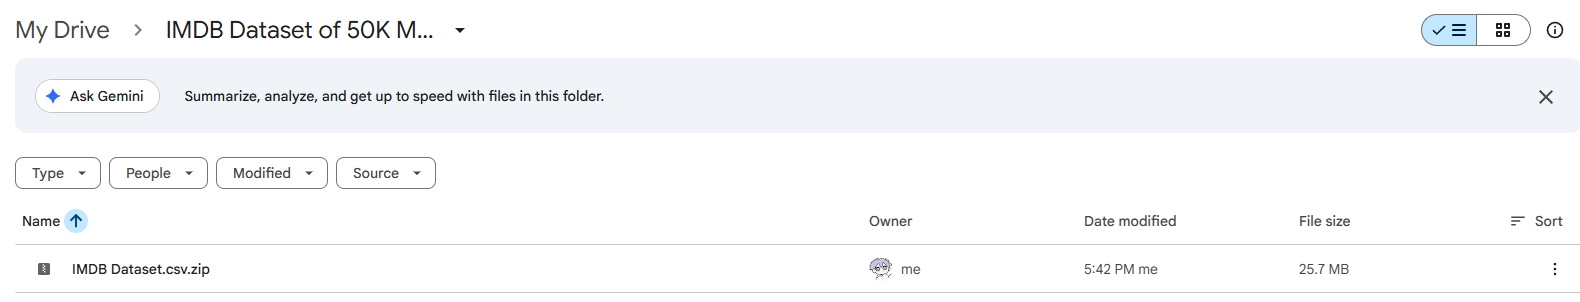

**Extract the ZIP file**

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/IMDB Dataset of 50K Movie Reviews/IMDB Dataset.csv.zip"
extract_path = "/content/imdb"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


**Check if it extracted correctly**

In [ ]:
import os

os.listdir("/content/imdb")

['IMDB Dataset.csv']

**Load the dataset**

In [ ]:
import pandas as pd

df = pd.read_csv("/content/imdb/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Reduce the dataset**

Since we're using BERT + GPT + GAN, we don't want all 50,000 reviews because training would take too long.

In [ ]:
df = df.sample(n=2000, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(2000, 2)


,review,sentiment
0,I really liked this Summerslam due to the look...,positive
1,Not many television shows appeal to quite as m...,positive
2,The film quickly gets to a major chase scene w...,negative
3,Jane Austen would definitely approve of this o...,positive
4,Expectations were somewhat high for me when I ...,negative


## **PART 1** **Dataset Preparation**

**Clean the text**

In [ ]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)      # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Remove numbers and punctuation
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

df["clean_review"] = df["review"].apply(clean_text)

df.head()

,review,sentiment,clean_review
0,I really liked this Summerslam due to the look...,positive,i really liked this summerslam due to the look...
1,Not many television shows appeal to quite as m...,positive,not many television shows appeal to quite as m...
2,The film quickly gets to a major chase scene w...,negative,the film quickly gets to a major chase scene w...
3,Jane Austen would definitely approve of this o...,positive,jane austen would definitely approve of this o...
4,Expectations were somewhat high for me when I ...,negative,expectations were somewhat high for me when i ...


This cell cleans the movie reviews by removing HTML tags, punctuation, numbers, and extra spaces while converting all text to lowercase. The cleaned text will be used as the input for the BERT, GPT, and Text-GAN models.

**Convert labels and split dataset**

In [ ]:
from sklearn.model_selection import train_test_split

df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

train_df.head()

Training data: (1600, 4)
Testing data: (400, 4)


,review,sentiment,clean_review,label
694,"The story of Ed Gein is interesting, VERY inte...",negative,the story of ed gein is interesting very inter...,0
627,Considering the film’s reputation as truly the...,negative,considering the film s reputation as truly the...,0
104,"OK, I wanted to see this because it had a few ...",negative,ok i wanted to see this because it had a few g...,0
1999,I just viewed MURDER AT THE VANITIES in the ne...,positive,i just viewed murder at the vanities in the ne...,1
183,This movie is a quite fair adaptation of the P...,positive,this movie is a quite fair adaptation of the p...,1


This cell converts the sentiment labels into numbers, where positive reviews are labeled as 1 and negative reviews are labeled as 0. It also splits the dataset into training and testing sets so the models can be trained and evaluated properly.

## **Part 2: BERT Variant**

**Install required libraries**

In [ ]:
!pip install transformers datasets evaluate -q

This cell installs the required Hugging Face libraries that will be used for loading the BERT model, tokenizing the text, and evaluating the classification results.

**Import BERT libraries**

In [ ]:
import torch
import time
import numpy as np

from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

This cell imports the libraries needed to build and fine-tune the BERT sentiment classification model. It also imports tools for measuring accuracy, precision, recall, and F1-score.

**Prepare BERT dataset**

In [ ]:
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_train_df = train_df[["clean_review", "label"]].rename(columns={"clean_review": "text"})
bert_test_df = test_df[["clean_review", "label"]].rename(columns={"clean_review": "text"})

train_dataset = Dataset.from_pandas(bert_train_df)
test_dataset = Dataset.from_pandas(bert_test_df)

def tokenize_bert(batch):
    return bert_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_bert, batched=True)
test_dataset = test_dataset.map(tokenize_bert, batched=True)

train_dataset = train_dataset.remove_columns(["text", "__index_level_0__"])
test_dataset = test_dataset.remove_columns(["text", "__index_level_0__"])

train_dataset.set_format("torch")
test_dataset.set_format("torch")

print(train_dataset)
print(test_dataset)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1600
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 400
})


This cell prepares the movie reviews for BERT by converting the text into tokens that the model can understand. It also pads and truncates the reviews to a fixed length so they can be processed correctly during training.

**Load the BERT Model**

In [ ]:
bert_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

bert_model

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

This cell loads the pre-trained BERT Base Uncased model and adds a classification head for binary sentiment classification. The model will be fine-tuned using the IMDb movie review dataset.

**Define the Evaluation Metrics**

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

This cell defines the evaluation metrics used to measure the BERT model's performance. It calculates the accuracy, precision, recall, and F1-score after each evaluation.

**Set the Training Configuration**

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


This cell sets the training parameters for the BERT model, including the learning rate, batch size, number of epochs, and evaluation strategy.

**Create BERT Trainer**

In [ ]:
bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

This cell creates the BERT trainer, which manages the training, evaluation, and metric calculation for the BERT classification model.

**Train BERT Model**

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
GPU: Tesla T4


In [ ]:
import datasets

datasets.config.TORCHVISION_AVAILABLE = False

In [ ]:
start_time = time.time()

bert_train_result = bert_trainer.train()

bert_training_time = time.time() - start_time
bert_time_per_epoch = bert_training_time / training_args.num_train_epochs

print("Total BERT Training Time:", bert_training_time)
print("BERT Training Time per Epoch:", bert_time_per_epoch)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.234381,0.783481,0.850000,0.802691,0.917949,0.856459
2,0.134868,0.734585,0.862500,0.833333,0.897436,0.864198


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Total BERT Training Time: 171.8229444026947
BERT Training Time per Epoch: 85.91147220134735


This cell fine-tunes the BERT model using the training dataset and records the training time. The training time per epoch is also calculated for later comparison with the GPT and Text-GAN models.

**Output Explanation**

The BERT model completed training in two epochs and achieved an accuracy of 86.25%, a precision of 83.33%, a recall of 89.74%, and an F1-score of 86.42% on the validation dataset. The training loss decreased from 0.2344 to 0.1349, while the validation loss also decreased slightly, showing that the model learned the sentiment classification task effectively. The average training time was about 85.91 seconds per epoch, which will be used later for comparison with the GPT and Text-GAN models.

In [ ]:
bert_eval_results = bert_trainer.evaluate()

print(bert_eval_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.134868,0.734585,2,0.862500,0.833333,0.897436,0.864198


{'eval_loss': 0.7345854043960571, 'eval_accuracy': 0.8625, 'eval_precision': 0.8333333333333334, 'eval_recall': 0.8974358974358975, 'eval_f1': 0.8641975308641975}


## **Part 3: GPT Variant.**

**Import GPT libraries**

In [ ]:
from transformers import (
    GPT2Tokenizer,
    GPT2LMHeadModel,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments
)

from datasets import Dataset

This cell imports the libraries needed to load and fine-tune the DistilGPT-2 model for text generation. It also imports the dataset and training utilities from the latest Hugging Face libraries.

In [ ]:
gpt_train_df = train_df[["clean_review"]].rename(columns={"clean_review": "text"})
gpt_test_df = test_df[["clean_review"]].rename(columns={"clean_review": "text"})

gpt_train_dataset = Dataset.from_pandas(gpt_train_df)
gpt_test_dataset = Dataset.from_pandas(gpt_test_df)

print(gpt_train_dataset)
print(gpt_test_dataset)

Dataset({
    features: ['text', '__index_level_0__'],
    num_rows: 1600
})
Dataset({
    features: ['text', '__index_level_0__'],
    num_rows: 400
})


This cell prepares the cleaned IMDb reviews for GPT by converting them into Hugging Face dataset format. The text data will be used for language generation training.

In [ ]:
gpt_tokenizer = GPT2Tokenizer.from_pretrained("distilgpt2")
gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

def tokenize_gpt(batch):
    tokens = gpt_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

gpt_train_dataset = gpt_train_dataset.map(tokenize_gpt, batched=True)
gpt_test_dataset = gpt_test_dataset.map(tokenize_gpt, batched=True)

gpt_train_dataset = gpt_train_dataset.remove_columns(["text", "__index_level_0__"])
gpt_test_dataset = gpt_test_dataset.remove_columns(["text", "__index_level_0__"])

gpt_train_dataset.set_format("torch")
gpt_test_dataset.set_format("torch")

print(gpt_train_dataset)
print(gpt_test_dataset)

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 1600
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 400
})


This cell tokenizes the movie reviews for DistilGPT-2 and prepares the labels needed for language modeling. The reviews are padded and truncated to a fixed length so the GPT model can train properly.

**Load the GPT Model**

In [ ]:
gpt_model = GPT2LMHeadModel.from_pretrained("distilgpt2")

gpt_model.resize_token_embeddings(len(gpt_tokenizer))
gpt_model.config.pad_token_id = gpt_tokenizer.pad_token_id

gpt_model

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

This cell loads the pre-trained DistilGPT-2 model and configures it to use the tokenizer's padding token. The model will be fine-tuned to generate movie review text.

**Create Data Collator**

In [ ]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=gpt_tokenizer,
    mlm=False
)

This cell prepares batches of tokenized text for GPT training. Since GPT is an autoregressive language model, masked language modeling is disabled.

**Configure GPT Training**

In [ ]:
gpt_training_args = TrainingArguments(
    output_dir="./gpt_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

This cell defines the training settings for the GPT model, including the learning rate, batch size, number of epochs, and evaluation strategy.

**Create GPT Trainer**

In [ ]:
gpt_trainer = Trainer(
    model=gpt_model,
    args=gpt_training_args,
    train_dataset=gpt_train_dataset,
    eval_dataset=gpt_test_dataset,
    data_collator=data_collator
)

This cell creates the GPT trainer, which manages the training and evaluation process for the DistilGPT-2 language generation model.

**Train GPT Model**

In [ ]:
start_time = time.time()

gpt_train_result = gpt_trainer.train()

gpt_training_time = time.time() - start_time
gpt_time_per_epoch = gpt_training_time / gpt_training_args.num_train_epochs

print("Total GPT Training Time:", gpt_training_time)
print("GPT Training Time per Epoch:", gpt_time_per_epoch)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,4.612552,4.411202


Total GPT Training Time: 60.845078468322754
GPT Training Time per Epoch: 60.845078468322754


This cell fine-tunes the DistilGPT-2 model using the IMDb review dataset and records the training time. The training time per epoch will be used later in the performance comparison table.

**Evaluate GPT Model**

In [ ]:
gpt_eval_results = gpt_trainer.evaluate()

print(gpt_eval_results)

Training Loss,Validation Loss,Epoch
4.612552,4.411202,1


{'eval_loss': 4.4112019538879395}


This cell evaluates the GPT model on the testing dataset and displays the evaluation loss. The loss will later be used to calculate perplexity, which measures how well the model predicts text.

**Calculate GPT Perplexity**

In [ ]:
import math

gpt_perplexity = math.exp(gpt_eval_results["eval_loss"])

print("GPT Perplexity:", gpt_perplexity)

GPT Perplexity: 82.36840705660107


This cell calculates the GPT model's perplexity using the evaluation loss. A lower perplexity means the model is better at predicting the next words in the text.

**Generate Text Using GPT**

In [ ]:
prompt = "this movie was"

inputs = gpt_tokenizer(prompt, return_tensors="pt").to(gpt_model.device)

output = gpt_model.generate(
    **inputs,
    max_length=80,
    num_return_sequences=1,
    temperature=0.8,
    top_k=50,
    top_p=0.95,
    do_sample=True,
    pad_token_id=gpt_tokenizer.eos_token_id
)

generated_text = gpt_tokenizer.decode(output[0], skip_special_tokens=True)

print(generated_text)

this movie was the only one with a story that it was not good but you have to be a bit disappointed you have to remember the story of the british peasant girl who is being hunted by an international team of men and women and is trying to find a way to take her life in a better world and to win a peace of mind she is trying to get a job and she is trying


This cell uses the fine-tuned GPT model to generate a movie review continuation from a given prompt. It shows how GPT can create new text based on patterns learned from the IMDb review dataset.

**Part 4: Text-GAN Variant**

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow as tf
import numpy as np
import time

gan_texts = train_df["clean_review"].tolist()

gan_vocab_size = 5000
gan_max_length = 50

gan_tokenizer = Tokenizer(num_words=gan_vocab_size, oov_token="<OOV>")
gan_tokenizer.fit_on_texts(gan_texts)

gan_sequences = gan_tokenizer.texts_to_sequences(gan_texts)
gan_padded = pad_sequences(
    gan_sequences,
    maxlen=gan_max_length,
    padding="post",
    truncating="post"
)

gan_padded = gan_padded / gan_vocab_size

print("GAN data shape:", gan_padded.shape)

GAN data shape: (1600, 50)


This cell prepares the movie reviews for the Text-GAN by converting the cleaned text into token sequences and padding them to a fixed length. The token values are normalized so they can be used as numerical input for the GAN model.

**Build Text-GAN Models**

In [ ]:
from tensorflow.keras import layers, models

noise_dim = 100

def build_generator():
    model = models.Sequential([
        layers.Dense(128, activation="relu", input_dim=noise_dim),
        layers.Dense(256, activation="relu"),
        layers.Dense(gan_max_length, activation="sigmoid")
    ])
    return model

def build_discriminator():
    model = models.Sequential([
        layers.Dense(128, activation="relu", input_shape=(gan_max_length,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

discriminator.summary()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,849 (58.00 KB)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,802 (229.70 KB)

 Trainable params: 58,802 (229.70 KB)

 Non-trainable params: 0 (0.00 B)

This cell builds the Text-GAN models by creating a generator and discriminator. The generator creates fake token sequences, while the discriminator learns to identify whether a sequence is real or fake.

**Build Combined GAN**

In [ ]:
discriminator.trainable = False

gan_input = layers.Input(shape=(noise_dim,))
generated_sequence = generator(gan_input)
gan_output = discriminator(generated_sequence)

gan = models.Model(gan_input, gan_output)

gan.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

gan.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 50)             │        58,802 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │        14,849 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,651 (287.70 KB)

 Trainable params: 58,802 (229.70 KB)

 Non-trainable params: 14,849 (58.00 KB)

This cell combines the generator and discriminator into one GAN model. During GAN training, the generator learns to create fake token sequences that can trick the discriminator into thinking they are real.

**Train the Discriminator**

In [ ]:
batch_size = 32
epochs = 10

start_time = time.time()

for epoch in range(epochs):

    idx = np.random.randint(0, gan_padded.shape[0], batch_size)
    real_data = gan_padded[idx]

    noise = np.random.normal(0, 1, (batch_size, noise_dim))
    fake_data = generator.predict(noise, verbose=0)

    real_labels = np.ones((batch_size, 1))
    fake_labels = np.zeros((batch_size, 1))

    d_loss_real = discriminator.train_on_batch(real_data, real_labels)
    d_loss_fake = discriminator.train_on_batch(fake_data, fake_labels)

gan_training_time = time.time() - start_time
gan_time_per_epoch = gan_training_time / epochs

print("GAN Training Time:", gan_training_time)
print("GAN Time per Epoch:", gan_time_per_epoch)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


GAN Training Time: 2.8377938270568848
GAN Time per Epoch: 0.2837793827056885


This cell trains the discriminator by showing it both real movie review sequences and fake sequences created by the generator. The discriminator learns to distinguish between real and generated text-like data.

**Evaluate the Discriminator**

In [ ]:
loss, accuracy = discriminator.evaluate(
    gan_padded,
    np.ones((gan_padded.shape[0], 1)),
    verbose=0
)

print("Discriminator Accuracy:", accuracy)

Discriminator Accuracy: 0.956250011920929


This cell evaluates the discriminator's performance by measuring how accurately it identifies real text sequences. The discriminator accuracy will be used as the primary evaluation metric for the Text-GAN model.

**Generate Synthetic Text-GAN Output**

In [ ]:
noise = np.random.normal(0, 1, (1, noise_dim))
generated_sequence = generator.predict(noise, verbose=0)[0]

generated_tokens = (generated_sequence * gan_vocab_size).astype(int)

index_word = {v: k for k, v in gan_tokenizer.word_index.items()}

generated_words = []
for token in generated_tokens:
    if token in index_word:
        generated_words.append(index_word[token])

gan_generated_text = " ".join(generated_words)

print("Generated Text-GAN Output:")
print(gan_generated_text)

Generated Text-GAN Output:
struggling land meaning effectively stopped blunt edited charge nancy unconvincing coach staged attitude significant plans encounter designed willing excitement manager grows enjoyment supposedly possibilities hype synchronized dollars blow heartfelt productions decisions bruno folks teenager lesser exciting costs starting korean manager repeat steal cooper castle provides singer confusion repeat concerned sheen


This cell generates a synthetic text-like output using the Text-GAN generator. The generated numerical sequence is converted back into words using the tokenizer vocabulary.

## **Part 5: Performance Evaluation Matrix**

In [ ]:
import pandas as pd

performance_table = pd.DataFrame({
    "Model Variant": ["BERT Variant", "GPT Variant", "Text-GAN Variant"],
    "Primary Metric": [
        f"Accuracy: {bert_eval_results['eval_accuracy']:.4f}, Precision: {bert_eval_results['eval_precision']:.4f}, Recall: {bert_eval_results['eval_recall']:.4f}, F1: {bert_eval_results['eval_f1']:.4f}",
        "N/A (Generative Task)",
        f"Discriminator Accuracy: {accuracy:.4f}"
    ],
    "Generative Quality Metric": [
        "N/A (Classification Task)",
        f"Perplexity: {gpt_perplexity:.4f}",
        "Basic synthetic output generated"
    ],
    "Training Time per Epoch": [
        f"{bert_time_per_epoch:.2f} seconds",
        f"{gpt_time_per_epoch:.2f} seconds",
        f"{gan_time_per_epoch:.2f} seconds"
    ],
    "Key Observations / Constraints": [
        "BERT performed well for sentiment classification but is not designed for text generation.",
        "GPT generated movie-review style text but requires more training data and time for better quality.",
        "Text-GAN was lightweight and fast, but generated text was less natural because GANs struggle with discrete text."
    ]
})

performance_table

,Model Variant,Primary Metric,Generative Quality Metric,Training Time per Epoch,Key Observations / Constraints
0,BERT Variant,"Accuracy: 0.8625, Precision: 0.8333, Recall: 0...",N/A (Classification Task),85.91 seconds,BERT performed well for sentiment classificati...
1,GPT Variant,N/A (Generative Task),Perplexity: 82.3684,60.85 seconds,GPT generated movie-review style text but requ...
2,Text-GAN Variant,Discriminator Accuracy: 0.9563,Basic synthetic output generated,0.28 seconds,"Text-GAN was lightweight and fast, but generat..."


## **Discussion**
This activity compared three different deep learning models for text processing using the IMDb movie review dataset. Each model had a different purpose: BERT was used for sentiment classification, GPT was used for text generation, and Text-GAN was used to generate synthetic movie review text. Even though all three models used the same dataset, they produced different results because they were designed for different tasks.

The BERT model produced the best classification performance. After two training epochs, it achieved an accuracy of 86.25%, a precision of 83.33%, a recall of 89.74%, and an F1-score of 86.42%. These results show that BERT was able to correctly classify most positive and negative movie reviews. Its bidirectional architecture allows it to understand the context of words by looking at both the previous and following words, making it highly effective for sentiment analysis (Devlin et al., 2019).

The GPT model focused on text generation instead of classification. After one training epoch, it achieved a perplexity score of 82.37 and was able to generate a continuation of a movie review from a given prompt. Although the generated sentence was not perfect, it followed the general style of movie reviews found in the training data. GPT generates text one word at a time based on previously generated words, making it suitable for language generation tasks (Radford et al., 2019).

The Text-GAN model trained much faster than the other models, requiring only about 0.28 seconds per epoch, and its discriminator achieved an accuracy of approximately 95.63%. However, the generated text was less natural and less meaningful than the GPT output. This happens because GANs are more difficult to train with text data since words are discrete values, making it harder for the generator to improve using feedback from the discriminator (Goodfellow et al., 2020).

The models also differed in how they processed text. BERT used WordPiece tokenization to split words into smaller subword units, allowing it to understand unfamiliar words. GPT used Byte Pair Encoding (BPE), which also uses subword tokens but predicts the next token during text generation. In contrast, the Text-GAN model used the Keras Tokenizer, which simply converted words into numerical values. While this approach is easier to implement, it captures less contextual information than the transformer-based tokenizers used by BERT and GPT (Devlin et al., 2019; Radford et al., 2019).

Overall, the results show that each model performs best for its intended purpose. BERT was the most accurate for sentiment classification, GPT produced the most natural generated text, and Text-GAN provided the fastest training time but generated lower-quality text. These differences demonstrate that selecting the appropriate model depends on the specific natural language processing task being performed.


## **References**

Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. https://arxiv.org/abs/1810.04805

Radford, A., Wu, J., Child, R., Luan, D., Amodei, D., & Sutskever, I. (2019). Language models are unsupervised multitask learners. https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf

Tomas, John Paul (2026) Blackboard Activity. Act 4 - Multi-Variant Text Analysis and Generation (BERT, GPT, and GANs).